In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf

In [2]:
tf.__version__

'2.21.0'

In [3]:
data = pd.read_csv('data\cardio_train1.csv')
data.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [4]:
data.isna().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [5]:
X = data.iloc[:, 1:-1]
y = data.iloc[:, -1]
y

0        0
1        1
2        1
3        1
4        0
        ..
69995    0
69996    1
69997    1
69998    1
69999    0
Name: cardio, Length: 70000, dtype: int64

In [6]:

ss = StandardScaler()
X = ss.fit_transform(X)
X

array([[-0.43606151,  1.36405487,  0.44345206, ..., -0.31087913,
        -0.23838436,  0.49416711],
       [ 0.30768633, -0.73310834, -1.01816804, ..., -0.31087913,
        -0.23838436,  0.49416711],
       [-0.24799666, -0.73310834,  0.07804703, ..., -0.31087913,
        -0.23838436, -2.02360695],
       ...,
       [-0.16328642,  1.36405487,  2.27047718, ..., -0.31087913,
         4.19490608, -2.02360695],
       [ 1.20058905, -0.73310834, -0.16555632, ..., -0.31087913,
        -0.23838436, -2.02360695],
       [ 0.43414373, -0.73310834,  0.68705541, ..., -0.31087913,
        -0.23838436,  0.49416711]], shape=(70000, 11))

In [7]:
np.shape(X)

(70000, 11)

In [8]:
y = pd.get_dummies(y)

In [9]:
y

,0,1
0,True,False
1,False,True
2,False,True
3,False,True
4,True,False
...,...,...
69995,True,False
69996,False,True
69997,False,True
69998,False,True


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=33123)

In [28]:
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(11,)),
    tf.keras.layers.Dense(11, activation='relu'),
    tf.keras.layers.Dense(30, activation='relu'),
    tf.keras.layers.Dense(2, activation='softmax')
])

In [29]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 30)             │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │            62 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 554 (2.16 KB)

 Trainable params: 554 (2.16 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
from tensorflow.keras.utils import plot_model

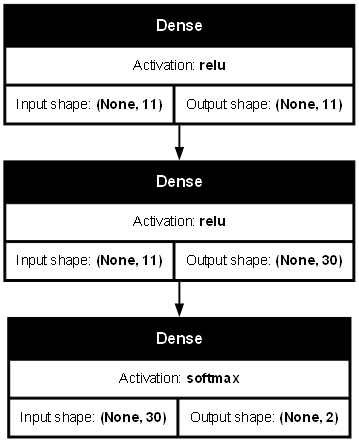

In [30]:
plot_model(model, show_layer_activations=True, show_shapes=True, dpi=70)

In [32]:
model.compile(tf.keras.optimizers.Adam(learning_rate=0.001), loss=tf.keras.losses.CategoricalCrossentropy(), metrics=[
              tf.keras.metrics.CategoricalAccuracy(), tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.F1Score()])

In [35]:
model.fit(X_train, y_train, epochs=100, validation_data=(
    X_test, y_test), batch_size=100)

Epoch 1/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - categorical_accuracy: 0.6369 - loss: 0.6415 - val_categorical_accuracy: 0.6470 - val_loss: 0.6306
Epoch 2/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - categorical_accuracy: 0.6637 - loss: 0.6191 - val_categorical_accuracy: 0.6866 - val_loss: 0.5987
Epoch 3/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - categorical_accuracy: 0.7063 - loss: 0.5784 - val_categorical_accuracy: 0.7173 - val_loss: 0.5658
Epoch 4/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - categorical_accuracy: 0.7236 - loss: 0.5584 - val_categorical_accuracy: 0.7261 - val_loss: 0.5551
Epoch 5/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - categorical_accuracy: 0.7267 - loss: 0.5532 - val_categorical_accuracy: 0.7307 - val_loss: 0.5504
Epoch 6/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - categorical_accuracy: 0.7301 - loss: 0.5522 - val_categorical_accuracy: 0.7304 - val_loss: 0.5486
Epoch 7/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - categorical_accuracy: 0.731

In [34]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(11,)),
    tf.keras.layers.Dense(11, activation='relu'),
    tf.keras.layers.Dense(30, activation='relu'),
    tf.keras.layers.Dense(60, activation='relu'),
    tf.keras.layers.Dense(25, activation='relu'),
    tf.keras.layers.Dense(2, activation='softmax')
])
model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss=tf.keras.losses.CategoricalCrossentropy(
), metrics=[tf.keras.metrics.CategoricalAccuracy()])

In [36]:
model.fit(X_train, y_train, epochs=100, validation_data=(
    X_test, y_test), batch_size=100)

Epoch 1/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - categorical_accuracy: 0.7459 - loss: 0.5248 - val_categorical_accuracy: 0.7317 - val_loss: 0.5546
Epoch 2/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - categorical_accuracy: 0.7468 - loss: 0.5245 - val_categorical_accuracy: 0.7292 - val_loss: 0.5533
Epoch 3/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - categorical_accuracy: 0.7453 - loss: 0.5245 - val_categorical_accuracy: 0.7299 - val_loss: 0.5567
Epoch 4/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - categorical_accuracy: 0.7453 - loss: 0.5243 - val_categorical_accuracy: 0.7287 - val_loss: 0.5616
Epoch 5/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - categorical_accuracy: 0.7460 - loss: 0.5243 - val_categorical_accuracy: 0.7298 - val_loss: 0.5540
Epoch 6/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - categorical_accuracy: 0.7455 - loss: 0.5240 - val_categorical_accuracy: 0.7269 - val_loss: 0.5544
Epoch 7/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - categorical_accuracy: 0.745

In [37]:
from sklearn.metrics import classification_report

In [44]:
y_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(y_true=y_test, y_pred=y_pred))

547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 841us/step
              precision    recall  f1-score   support

           0       0.71      0.74      0.73      8652
           1       0.74      0.71      0.72      8848

    accuracy                           0.72     17500
   macro avg       0.73      0.73      0.72     17500
weighted avg       0.73      0.72      0.72     17500

